In [1]:
from langchain_google_genai import GoogleGenerativeAI
from dotenv import find_dotenv,load_dotenv
import os 

if os.environ["GOOGLE_API_KEY"]:
    print(f"The API key is found , Success")
else:
    print(f'The API key is not found, ValueError')

The API key is found , Success


In [2]:
llm=GoogleGenerativeAI(model="gemini-2.5-flash-lite")

# Step 1 : Create Pydantic Schema

In [3]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):

    topic:str=Field(description="The topic of the post ")
    post:str=Field(description="The content of the LinkedIn post")
    curated_post:str=Field(description="The curated content of the LinkedIn post")

# Step 2 : Nodes or Node Functions


In [13]:
def create_post(state: graph_schema) -> graph_schema:
    state = state.model_dump()
    topic = state['topic']
    post = llm.invoke(f'Create a LinkedIn post about {topic} in 50 words ')
    state['post'] = post
    return state

def curate_post(state: graph_schema) -> graph_schema:
    state = state.model_dump()
    topic = state['topic']
    post = state['post']
    curated_post = llm.invoke(
        f'Please curate the LinkedIn post in GenZ style with the topic {topic} and the post content {post}'
    )
    state['curated_post'] = curated_post
    return state

In [14]:
# Create and Compile the graph
from langgraph.graph import StateGraph,START,END

graph=StateGraph(state_schema=graph_schema)


graph.add_node('create_post',create_post)
graph.add_node('curate_post',curate_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)



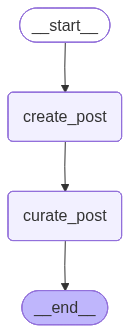

In [15]:
from IPython.display import Image,display

pydantic_graph=graph.compile()


Image(pydantic_graph.get_graph().draw_mermaid_png())


In [17]:
pydantic_graph.invoke(
    {
        "topic":"Why is bacth size kept 32 ?",
        "post":" ",
        "curated_post":" "
    }
)

{'topic': 'Why is bacth size kept 32 ?',
 'post': 'Why 32? Batch size 32 is a common starting point in deep learning. It offers a good balance: small enough for generalization, large enough for efficient gradient estimation, and often fits well into GPU memory, making training faster. #DeepLearning #MachineLearning #BatchSize',
 'curated_post': 'Here are a few Gen Z-style LinkedIn post options for the topic "Why is batch size kept at 32?":\n\n---\n\n**Option 1: Short & Punchy with Emojis**\n\n**Headline:** Batch Size 32? It\'s not random, fam. 🤯\n\n**Content:**\nOkay, so why is batch size 32 the GO-TO in deep learning? 🤔 It\'s kinda the sweet spot.\n\nSmall enough to keep the model from being extra and actually learn new stuff (aka generalization). ✅\nBig enough to get a decent idea of the "vibe" of the data for gradient updates (efficient gradient estimation). 📈\nPlus, it usually vibes with GPU memory, so training is faster. 🚀 Less waiting, more building.\n\n#DeepLearning #MachineLear